# 12 — Solar Parameter Replacement Analysis (Cooling Mode)

**Purpose:** Determine which Open Meteo radiation variable best replaces
`PV_Generate` and `pv_forecast_*h` in:
1. **Offline calibration** (`physics_calibration_cooling.py` → `_residual_heat_source_weight()`)
2. **Live thermal model** (`thermal_equilibrium_model.py` → `predict_equilibrium_temperature()`)
3. **ML overheating classifier** (NB09 features: PV_Generate + 12× pv_forecast)

**Parameter weight semantics:**
- Current: `pv_heat_weight` [kW/W] × `PV_Generate` [W] = `Q_pv` [kW]
- With GHI: `ghi_heat_weight` [kW/(W/m²)] × `GHI` [W/m²] = `Q_solar` [kW]
- The weight absorbs panel area, orientation, efficiency, and window solar gain
- Other params (`solar_lag_minutes`, `cloud_factor_exponent`, `solar_decay_tau_hours`) are dimensionless/temporal — semantics unchanged

**Learning path impact:**
- `SolarChannel.apply_gradient_update()` bounds: pv_heat_weight ∈ [0.0001, 0.005] with ±0.0002 step limit
- Current calibrated value: 0.000309 kW/W
- GHI replacement: weight must account for ~30 m² panel area → expect `ghi_weight ≈ pv_weight × PV_mean / GHI_mean`

**Data:** `cooling_training_data.csv.gz` (47,941 rows) + Open Meteo archive (9,504 hours)

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings, calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize, stats, signal
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "Logs_and_models" / "cooling_training_data.csv.gz"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH, "exists:", DATA_PATH.exists())

Project root: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor
Data path: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\Logs_and_models\cooling_training_data.csv.gz exists: True


## Section A: Data Preparation

In [2]:
# Load cooling training data
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")

# Reconstruct hour from sin/cos
df["hour"] = (np.degrees(np.arctan2(df["hour_sin"], df["hour_cos"])) / 15) % 24

# Key derived columns
df["driving_force"] = df["indoor_temp"] - df["AT"]
df["cooling_drive"] = df["indoor_temp"] - df["VLT"]

# Clean sensor errors
mask_clean = (df["AT"] > -10) & (df["AT"] < 45) & (df["VLT"] > 10) & (df["VLT"] < 45)
df_clean = df[mask_clean].copy()

# Identify periods
df_clean["is_cooling_active"] = (df_clean["is_hp_active"] == 1) & (df_clean["delta_t"] < -0.5)
df_clean["is_night"] = (df_clean["hour"] < 6) | (df_clean["hour"] > 21)
df_clean["has_pv"] = df_clean["PV_Generate"] > 50

# DOY for merging
doy_angle = np.arctan2(df_clean["doy_sin"], df_clean["doy_cos"])
doy = (doy_angle * 365.25 / (2 * np.pi)) % 365.25
df_clean["doy_approx"] = doy.round().astype(int).clip(1, 365)
df_clean["hour_approx"] = df_clean["hour"].round().astype(int).clip(0, 23)

print(f"Clean: {len(df_clean)} rows, Cooling active: {df_clean['is_cooling_active'].sum()}")
print(f"PV stats: mean={df_clean['PV_Generate'].mean():.0f}W, "
      f"max={df_clean['PV_Generate'].max():.0f}W, "
      f"PV>50W: {df_clean['has_pv'].sum()} ({100*df_clean['has_pv'].mean():.1f}%)")

Shape: (47941, 76)
Clean: 47933 rows, Cooling active: 6094
PV stats: mean=2242W, max=14210W, PV>50W: 32573 (68.0%)


In [3]:
import requests, urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

LAT, LON = 48.928, 10.069
HOURLY_VARS = (
    "shortwave_radiation,direct_radiation,diffuse_radiation,"
    "direct_normal_irradiance,global_tilted_irradiance_instant,"
    "sunshine_duration"
)

def fetch_open_meteo_chunk(start_date, end_date, hourly_vars=HOURLY_VARS):
    url = (
        f"https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={LAT}&longitude={LON}"
        f"&start_date={start_date}&end_date={end_date}"
        f"&hourly={hourly_vars}"
        f"&timezone=Europe%2FBerlin"
    )
    resp = requests.get(url, timeout=60, verify=False)
    resp.raise_for_status()
    data = resp.json()
    if "error" in data:
        raise ValueError(data.get("reason", data["error"]))
    return data

# Fetch monthly chunks May 2025 - May 2026
chunks = []
fetch_errors = []
print("Fetching Open Meteo archive (verify=False for corporate proxy)...")

month_starts = []
y, m = 2025, 5
while (y, m) <= (2026, 5):
    month_starts.append((y, m))
    m += 1
    if m > 12:
        m, y = 1, y + 1

for y, m in month_starts:
    last_day = calendar.monthrange(y, m)[1]
    s_str, e_str = f"{y}-{m:02d}-01", f"{y}-{m:02d}-{last_day:02d}"
    try:
        data = fetch_open_meteo_chunk(s_str, e_str)
        hourly = data["hourly"]
        chunk_df = pd.DataFrame({"timestamp": pd.to_datetime(hourly["time"])})
        for var in ["shortwave_radiation", "direct_radiation", "diffuse_radiation",
                    "direct_normal_irradiance"]:
            if var in hourly:
                chunk_df[var] = hourly[var]
        # Optional vars
        for var in ["global_tilted_irradiance_instant", "sunshine_duration"]:
            if var in hourly and hourly[var] is not None:
                chunk_df[var] = hourly[var]
        chunks.append(chunk_df)
        print(f"  {s_str} to {e_str}: {len(chunk_df)} hours OK")
    except Exception as e:
        fetch_errors.append((s_str, str(e)[:80]))
        print(f"  {s_str} to {e_str}: FAILED ({str(e)[:80]})")

solar_df = pd.concat(chunks, ignore_index=True).set_index("timestamp").sort_index()
solar_df = solar_df[~solar_df.index.duplicated(keep="first")]

# Rename for clarity
rename_map = {
    "shortwave_radiation": "ghi_wm2",
    "direct_radiation": "direct_wm2",
    "diffuse_radiation": "diffuse_wm2",
    "direct_normal_irradiance": "dni_wm2",
}
if "global_tilted_irradiance_instant" in solar_df.columns:
    rename_map["global_tilted_irradiance_instant"] = "gti_wm2"
if "sunshine_duration" in solar_df.columns:
    rename_map["sunshine_duration"] = "sunshine_sec"
solar_df = solar_df.rename(columns=rename_map)

print(f"\nTotal: {len(solar_df)} hourly records")
print(f"Date range: {solar_df.index.min()} to {solar_df.index.max()}")
print(f"Columns: {list(solar_df.columns)}")
display(solar_df.describe().round(1))

Fetching Open Meteo archive (verify=False for corporate proxy)...
  2025-05-01 to 2025-05-31: 744 hours OK
  2025-06-01 to 2025-06-30: 720 hours OK
  2025-07-01 to 2025-07-31: 744 hours OK
  2025-08-01 to 2025-08-31: 744 hours OK
  2025-09-01 to 2025-09-30: 720 hours OK
  2025-10-01 to 2025-10-31: 744 hours OK
  2025-11-01 to 2025-11-30: 720 hours OK
  2025-12-01 to 2025-12-31: 744 hours OK
  2026-01-01 to 2026-01-31: 744 hours OK
  2026-02-01 to 2026-02-28: 672 hours OK
  2026-03-01 to 2026-03-31: 744 hours OK
  2026-04-01 to 2026-04-30: 720 hours OK
  2026-05-01 to 2026-05-31: 744 hours OK

Total: 9504 hourly records
Date range: 2025-05-01 00:00:00 to 2026-05-31 23:00:00
Columns: ['ghi_wm2', 'direct_wm2', 'diffuse_wm2', 'dni_wm2', 'gti_wm2', 'sunshine_sec']


,ghi_wm2,direct_wm2,diffuse_wm2,dni_wm2,gti_wm2,sunshine_sec
count,9504.0,9504.0,9504.0,9504.0,9504.0,9504.0
mean,156.5,97.5,59.0,184.2,156.2,1245.1
std,231.0,178.7,80.7,278.4,232.3,1667.4
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0
50%,9.0,0.0,8.0,0.0,6.0,0.0
75%,252.0,110.0,101.0,333.4,252.0,3600.0
max,918.0,813.0,414.0,928.6,919.3,3600.0


In [4]:
# Average by DOY + hour (climatological match — training data lacks timestamps)
solar_df["doy"] = solar_df.index.dayofyear
solar_df["hour_of_day"] = solar_df.index.hour

solar_cols = [c for c in solar_df.columns if c not in ["doy", "hour_of_day"]]
solar_avg = solar_df.groupby(["doy", "hour_of_day"])[solar_cols].mean().reset_index()

df_merged = df_clean.merge(
    solar_avg,
    left_on=["doy_approx", "hour_approx"],
    right_on=["doy", "hour_of_day"],
    how="left"
)

print(f"Merged: {len(df_merged)} rows")
for col in solar_cols:
    matched = df_merged[col].notna().sum()
    print(f"  {col}: {matched} matched ({100*matched/len(df_merged):.1f}%)")

# PV-to-GHI scaling factor (for weight conversion)
pv_nonzero = df_merged[(df_merged["PV_Generate"] > 50) & (df_merged["ghi_wm2"] > 10)]
pv_ghi_ratio = pv_nonzero["PV_Generate"].mean() / pv_nonzero["ghi_wm2"].mean()
print(f"\nPV/GHI mean ratio: {pv_ghi_ratio:.2f} W / (W/m2)")
print(f"  → If pv_heat_weight = 0.000309 kW/W")
print(f"  → Expected ghi_heat_weight = {0.000309 * pv_ghi_ratio:.6f} kW/(W/m2)")

Merged: 47933 rows
  ghi_wm2: 47933 matched (100.0%)
  direct_wm2: 47933 matched (100.0%)
  diffuse_wm2: 47933 matched (100.0%)
  dni_wm2: 47933 matched (100.0%)
  gti_wm2: 47933 matched (100.0%)
  sunshine_sec: 47933 matched (100.0%)

PV/GHI mean ratio: 8.66 W / (W/m2)
  → If pv_heat_weight = 0.000309 kW/W
  → Expected ghi_heat_weight = 0.002674 kW/(W/m2)


## Section B: Correlation Matrix — Solar × PV × Thermal

**Key question:** Which Open Meteo variable correlates best with:
1. `PV_Generate` (can it substitute the measurement?)
2. `indoor_trend_30m` (does it predict indoor temp change better than PV?)
3. `thermal_power_kw` (does it correlate with cooling demand?)

**Learning path impact:** The variable with highest correlation to `indoor_trend_30m`
is the best candidate for `Q_ext` in the equilibrium equation, because that's the
physical effect we're trying to model (solar heat gain → indoor temp rise).

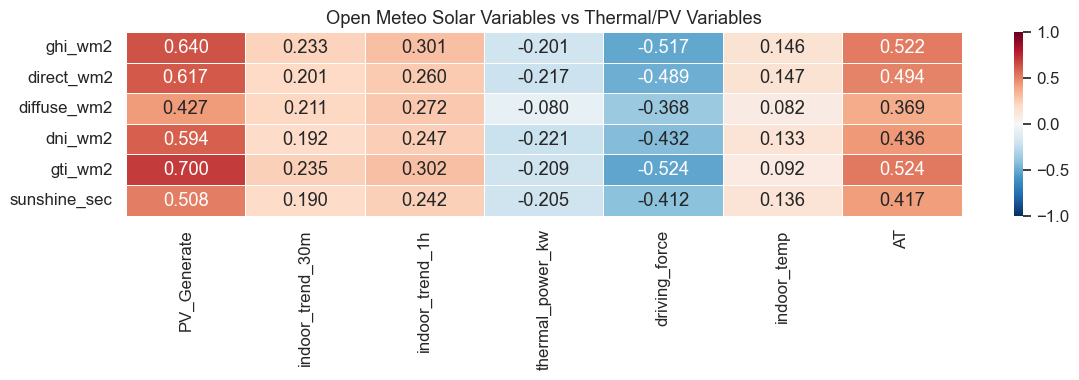


Sorted by |r| with indoor_trend_30m:
  gti_wm2                              r(trend)=+0.2351  r(PV)=+0.6997
  ghi_wm2                              r(trend)=+0.2329  r(PV)=+0.6403
  diffuse_wm2                          r(trend)=+0.2108  r(PV)=+0.4274
  direct_wm2                           r(trend)=+0.2011  r(PV)=+0.6169
  dni_wm2                              r(trend)=+0.1920  r(PV)=+0.5939
  sunshine_sec                         r(trend)=+0.1896  r(PV)=+0.5083


In [5]:
# Full correlation matrix: solar vars vs thermal vars
solar_var_cols = [c for c in solar_cols if df_merged[c].notna().sum() > 1000]
thermal_vars = ["PV_Generate", "indoor_trend_30m", "indoor_trend_1h",
                "thermal_power_kw", "driving_force", "indoor_temp", "AT"]

corr_cols = solar_var_cols + thermal_vars
corr_data = df_merged[corr_cols].dropna()
corr_matrix = corr_data.corr()

# Extract just the cross-correlations (solar × thermal)
cross_corr = corr_matrix.loc[solar_var_cols, thermal_vars]

fig, ax = plt.subplots(figsize=(12, max(4, len(solar_var_cols) * 0.6)))
sns.heatmap(cross_corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Open Meteo Solar Variables vs Thermal/PV Variables")
plt.tight_layout()
plt.show()

# Print sorted by indoor_trend correlation
print("\nSorted by |r| with indoor_trend_30m:")
trend_corrs = cross_corr["indoor_trend_30m"].abs().sort_values(ascending=False)
for var, r in trend_corrs.items():
    r_signed = cross_corr.loc[var, "indoor_trend_30m"]
    r_pv = cross_corr.loc[var, "PV_Generate"]
    print(f"  {var:35s}  r(trend)={r_signed:+.4f}  r(PV)={r_pv:+.4f}")

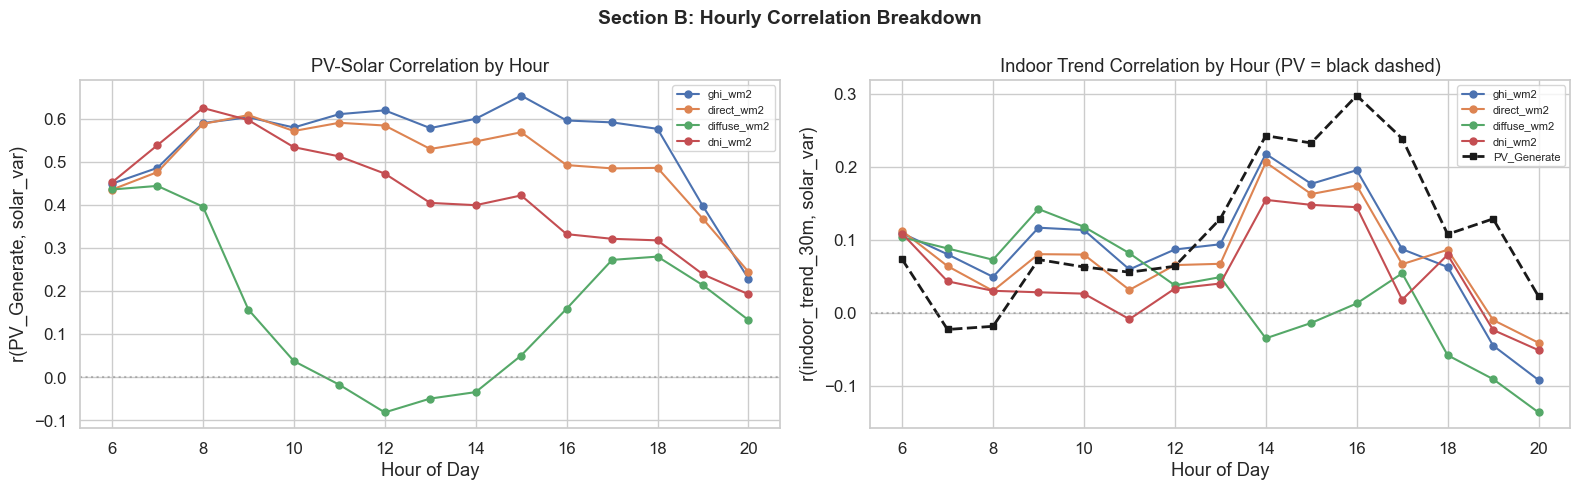

In [6]:
# Correlations by hour of day (solar angle matters!)
daytime_hours = range(6, 21)  # 6 AM to 9 PM
hourly_corrs = []

for h in daytime_hours:
    mask = (df_merged["hour_approx"] == h) & df_merged["ghi_wm2"].notna()
    subset = df_merged[mask]
    if len(subset) < 50:
        continue
    row = {"hour": h, "n": len(subset)}
    for solar_col in solar_var_cols:
        if solar_col in subset.columns and subset[solar_col].notna().sum() > 20:
            row[f"r_PV_{solar_col}"] = subset["PV_Generate"].corr(subset[solar_col])
            row[f"r_trend_{solar_col}"] = subset["indoor_trend_30m"].corr(subset[solar_col])
    hourly_corrs.append(row)

hourly_df = pd.DataFrame(hourly_corrs).set_index("hour")

# Plot: PV vs GHI correlation by hour
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for col in solar_var_cols[:4]:  # First 4 solar vars
    r_col = f"r_PV_{col}"
    if r_col in hourly_df.columns:
        ax.plot(hourly_df.index, hourly_df[r_col], "o-", ms=5, label=col)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("r(PV_Generate, solar_var)")
ax.set_title("PV-Solar Correlation by Hour")
ax.legend(fontsize=8)
ax.axhline(0, color="gray", ls=":", alpha=0.5)

ax = axes[1]
for col in solar_var_cols[:4]:
    r_col = f"r_trend_{col}"
    if r_col in hourly_df.columns:
        ax.plot(hourly_df.index, hourly_df[r_col], "o-", ms=5, label=col)
# Also show PV vs trend
pv_trend_hourly = []
for h in daytime_hours:
    mask = df_merged["hour_approx"] == h
    subset = df_merged[mask]
    if len(subset) > 50:
        pv_trend_hourly.append((h, subset["PV_Generate"].corr(subset["indoor_trend_30m"])))
if pv_trend_hourly:
    hh, rr = zip(*pv_trend_hourly)
    ax.plot(hh, rr, "k--", ms=5, lw=2, label="PV_Generate", marker="s")

ax.set_xlabel("Hour of Day")
ax.set_ylabel("r(indoor_trend_30m, solar_var)")
ax.set_title("Indoor Trend Correlation by Hour (PV = black dashed)")
ax.legend(fontsize=8)
ax.axhline(0, color="gray", ls=":", alpha=0.5)

plt.suptitle("Section B: Hourly Correlation Breakdown", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Lag analysis on 6094 cooling-active rows
  ghi_wm2                  : peak |r|=0.3055 at lag=+0 min
  direct_wm2               : peak |r|=0.2776 at lag=+5 min
  diffuse_wm2              : peak |r|=0.2129 at lag=+0 min
  dni_wm2                  : peak |r|=0.2721 at lag=+5 min
  PV_Generate              : peak |r|=0.2931 at lag=-5 min


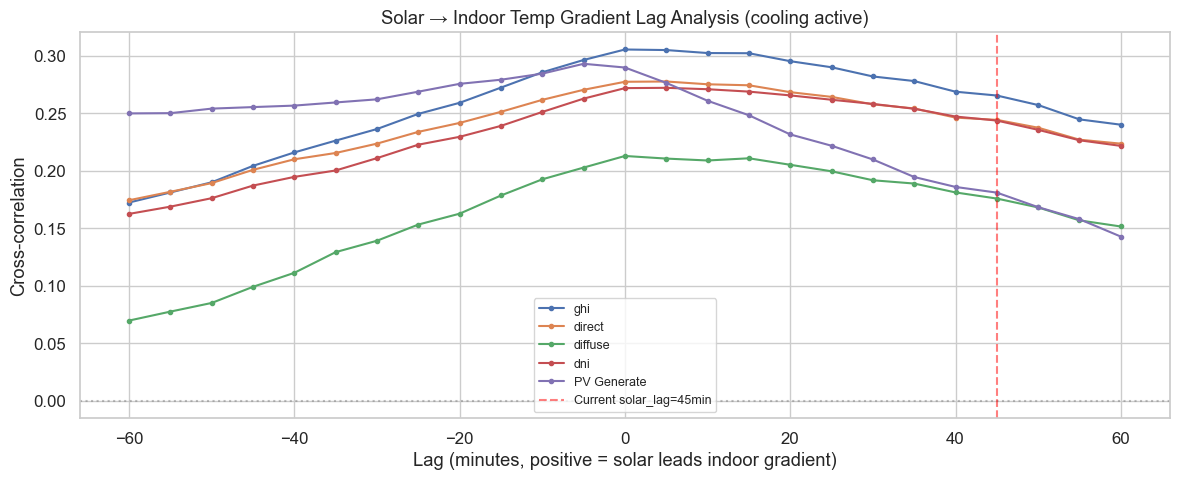

In [7]:
# Lag analysis: cross-correlate solar vars vs indoor_temp_gradient
# Compare to _calibrate_solar_lag_xcorr() which searches 0-60 min
# Training data is 5-min resolution → lags 0-12 steps = 0-60 min

max_lag_steps = 12  # 60 minutes at 5-min resolution

cooling_only = df_merged[df_merged["is_cooling_active"]].copy()
print(f"Lag analysis on {len(cooling_only)} cooling-active rows")

lag_results = {}
for solar_col in ["ghi_wm2", "direct_wm2", "diffuse_wm2", "dni_wm2", "PV_Generate"]:
    if solar_col not in cooling_only.columns:
        continue
    valid = cooling_only[[solar_col, "indoor_temp_gradient"]].dropna()
    if len(valid) < 100:
        continue

    x = valid[solar_col].values
    y = valid["indoor_temp_gradient"].values

    # Normalize
    x = (x - x.mean()) / (x.std() + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)

    # Cross-correlation at different lags
    corrs = []
    for lag in range(-max_lag_steps, max_lag_steps + 1):
        if lag >= 0:
            r = np.corrcoef(x[lag:], y[:len(y)-lag])[0, 1] if lag < len(x) else 0
        else:
            r = np.corrcoef(x[:len(x)+lag], y[-lag:])[0, 1] if -lag < len(y) else 0
        corrs.append((lag * 5, r))  # Convert steps to minutes

    lag_results[solar_col] = corrs
    best_lag, best_r = max(corrs, key=lambda x: abs(x[1]))
    print(f"  {solar_col:25s}: peak |r|={abs(best_r):.4f} at lag={best_lag:+d} min")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
for col, corrs in lag_results.items():
    lags, rs = zip(*corrs)
    label = col.replace("_wm2", "").replace("_", " ")
    ax.plot(lags, rs, "o-", ms=3, label=label)
ax.set_xlabel("Lag (minutes, positive = solar leads indoor gradient)")
ax.set_ylabel("Cross-correlation")
ax.set_title("Solar → Indoor Temp Gradient Lag Analysis (cooling active)")
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.axvline(45, color="red", ls="--", alpha=0.5, label="Current solar_lag=45min")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Section C: Thermal Model Calibration with Solar Variants

Calibrate the dual-HLC Newton model (best from NB10) using each solar variable.
The model predicts indoor temperature trajectory:

$$T_{eq} = \frac{OE \cdot T_{outlet} + HLC \cdot T_{outdoor} + Q_{solar}}{OE + HLC}$$
$$T(t+dt) = T(t) + (T_{eq} - T(t)) \cdot (1 - e^{-dt/\tau})$$

where $Q_{solar} = solar\_value \times solar\_weight$ (with tanh saturation at 3.0 kW).

**Parameter weight semantics:**
- `pv_heat_weight` [kW/W]: calibrated=0.000309, bounds [0.0001, 0.005]
- For GHI [W/m²]: expect `ghi_weight ≈ pv_weight × (PV_mean / GHI_mean)`
- The weight absorbs: panel area, orientation, efficiency, window gain factor

**Learning path:** `SolarChannel.apply_gradient_update()` clips delta to ±0.0002 per step.
Bounds must be adjusted if the new weight has different scale.

In [8]:
def predict_equilibrium(T_outlet, T_outdoor, HLC, OE, solar_val=0, solar_w=0):
    Q_ext = solar_val * solar_w
    # Tanh saturation (same as production: MAX_SOLAR_CONTRIBUTION=3.0)
    if abs(Q_ext) > 0:
        Q_ext = 3.0 * np.tanh(Q_ext / 3.0)
    return (OE * T_outlet + HLC * T_outdoor + Q_ext) / (OE + HLC)

def cost_dual_hlc_solar(params, data, solar_col):
    HLC_on, HLC_off, OE, tau, solar_w = params
    if HLC_on < 0.01 or HLC_off < 0.001 or OE < 0.05 or tau < 1.0 or solar_w < 0:
        return 1e6

    pred = np.zeros(len(data))
    pred[0] = data["indoor_temp"].iloc[0]
    hp_active = data["is_hp_active"].values
    solar_vals = data[solar_col].fillna(0).values if solar_col in data.columns else np.zeros(len(data))
    dt_h = 5 / 60

    for i in range(1, len(data)):
        hlc_i = HLC_on if hp_active[i] == 1 else HLC_off
        T_eq = predict_equilibrium(
            data["VLT"].iloc[i], data["AT"].iloc[i], hlc_i, OE,
            solar_vals[i], solar_w
        )
        approach = 1 - np.exp(-dt_h / tau)
        pred[i] = pred[i-1] + (T_eq - pred[i-1]) * approach

    if np.any(np.isnan(pred)):
        return 1e6
    return np.mean((pred - data["indoor_temp"].values) ** 2)

# Prepare mixed-mode calibration data (HP-ON + HP-OFF, same as NB10)
max_rows = 5000
cal_data = df_merged.head(max_rows).copy()
print(f"Calibration data: {len(cal_data)} rows, "
      f"HP-ON: {cal_data['is_hp_active'].sum()}, "
      f"HP-OFF: {(~cal_data['is_hp_active'].astype(bool)).sum()}")

# Bounds: HLC_on, HLC_off, OE, tau, solar_weight
# solar_weight bounds depend on the variable scale
pv_mean = cal_data["PV_Generate"].mean()
ghi_mean = cal_data["ghi_wm2"].dropna().mean()
scale_ratio = pv_mean / (ghi_mean + 1e-8)
print(f"PV mean: {pv_mean:.0f} W, GHI mean: {ghi_mean:.1f} W/m2, ratio: {scale_ratio:.2f}")

solar_variants = {}
# Define variants with appropriate weight bounds
variant_config = {
    "PV_Generate": {
        "col": "PV_Generate",
        "w_bounds": (0.0, 0.01),
        "label": "PV (local panel)",
        "units": "kW/W"
    },
    "ghi_wm2": {
        "col": "ghi_wm2",
        "w_bounds": (0.0, 0.01 * scale_ratio),
        "label": "GHI (Global Horiz.)",
        "units": "kW/(W/m2)"
    },
    "direct_wm2": {
        "col": "direct_wm2",
        "w_bounds": (0.0, 0.01 * scale_ratio),
        "label": "Direct Radiation",
        "units": "kW/(W/m2)"
    },
    "dni_wm2": {
        "col": "dni_wm2",
        "w_bounds": (0.0, 0.01 * scale_ratio),
        "label": "DNI (Direct Normal)",
        "units": "kW/(W/m2)"
    },
    "diffuse_wm2": {
        "col": "diffuse_wm2",
        "w_bounds": (0.0, 0.01 * scale_ratio * 2),
        "label": "Diffuse Radiation",
        "units": "kW/(W/m2)"
    },
}

# Add GTI if available
if "gti_wm2" in cal_data.columns and cal_data["gti_wm2"].notna().sum() > 1000:
    variant_config["gti_wm2"] = {
        "col": "gti_wm2",
        "w_bounds": (0.0, 0.01 * scale_ratio),
        "label": "GTI (Tilted)",
        "units": "kW/(W/m2)"
    }

# No-solar baseline
print("\nCalibrating dual-HLC model with each solar variant...")
print(f"{'Variant':<25s} {'RMSE':>8s} {'HLC_on':>8s} {'HLC_off':>8s} {'OE':>8s} {'tau':>6s} {'w':>12s} {'units'}")
print("-" * 95)

# Baseline: no solar
COMMON_BOUNDS = [(0.02, 0.5), (0.005, 0.3), (0.1, 1.0), (1.5, 15.0)]
res_base = optimize.differential_evolution(
    cost_dual_hlc_solar,
    COMMON_BOUNDS + [(0, 0)],  # Fix solar_w=0
    args=(cal_data, "PV_Generate"),
    maxiter=300, seed=42, tol=1e-6
)
rmse_base = np.sqrt(res_base.fun)
solar_variants["No solar"] = {
    "params": res_base.x, "rmse": rmse_base, "w": 0, "units": "-"
}
print(f"{'No solar':<25s} {rmse_base:>8.4f} {res_base.x[0]:>8.4f} {res_base.x[1]:>8.4f} "
      f"{res_base.x[2]:>8.4f} {res_base.x[3]:>6.2f} {'0':>12s} {'-'}")

for name, cfg in variant_config.items():
    col = cfg["col"]
    if col not in cal_data.columns or cal_data[col].notna().sum() < 1000:
        print(f"{cfg['label']:<25s} SKIPPED (insufficient data)")
        continue

    bounds = COMMON_BOUNDS + [cfg["w_bounds"]]
    try:
        res = optimize.differential_evolution(
            cost_dual_hlc_solar,
            bounds,
            args=(cal_data, col),
            maxiter=500, seed=42, tol=1e-6
        )
        rmse = np.sqrt(res.fun)
        solar_variants[cfg["label"]] = {
            "params": res.x, "rmse": rmse,
            "w": res.x[4], "units": cfg["units"],
            "col": col
        }
        print(f"{cfg['label']:<25s} {rmse:>8.4f} {res.x[0]:>8.4f} {res.x[1]:>8.4f} "
              f"{res.x[2]:>8.4f} {res.x[3]:>6.2f} {res.x[4]:>12.6f} {cfg['units']}")
    except Exception as e:
        print(f"{cfg['label']:<25s} FAILED: {e}")

# Best variant
best_name = min(solar_variants, key=lambda k: solar_variants[k]["rmse"])
print(f"\n*** BEST: {best_name} (RMSE={solar_variants[best_name]['rmse']:.4f}) ***")
print(f"    Improvement over no-solar: {rmse_base - solar_variants[best_name]['rmse']:.4f} C")

Calibration data: 5000 rows, HP-ON: 2212.0, HP-OFF: 2788
PV mean: 2203 W, GHI mean: 277.4 W/m2, ratio: 7.94

Calibrating dual-HLC model with each solar variant...
Variant                       RMSE   HLC_on  HLC_off       OE    tau            w units
-----------------------------------------------------------------------------------------------
No solar                    0.9145   0.5000   0.0050   0.8833  15.00            0 -
PV (local panel)            0.5280   0.5000   0.0732   0.6594  15.00     0.000493 kW/W
GHI (Global Horiz.)         0.4759   0.5000   0.0878   0.6282  15.00     0.004144 kW/(W/m2)
Direct Radiation            0.5254   0.5000   0.0351   0.6543  15.00     0.004935 kW/(W/m2)
DNI (Direct Normal)         0.5321   0.5000   0.0328   0.6578  15.00     0.002963 kW/(W/m2)
Diffuse Radiation           0.4603   0.5000   0.1803   0.5903  15.00     0.018258 kW/(W/m2)
GTI (Tilted)                0.4763   0.5000   0.0902   0.6280  15.00     0.004228 kW/(W/m2)

*** BEST: Diffuse Rad

In [9]:
# Weight conversion: how does ghi_weight relate to pv_weight?
print("=== WEIGHT CONVERSION ANALYSIS ===")
print()

pv_result = solar_variants.get("PV (local panel)")
ghi_result = solar_variants.get("GHI (Global Horiz.)")

if pv_result and ghi_result:
    w_pv = pv_result["w"]
    w_ghi = ghi_result["w"]

    # Effective thermal contribution at typical conditions
    typical_pv = 5000  # W (midday peak)
    typical_ghi = 600  # W/m2 (midday peak)

    Q_pv = typical_pv * w_pv  # kW
    Q_ghi = typical_ghi * w_ghi  # kW

    print(f"Calibrated weights:")
    print(f"  pv_heat_weight  = {w_pv:.6f} kW/W")
    print(f"  ghi_heat_weight = {w_ghi:.6f} kW/(W/m2)")
    print()
    print(f"Thermal contribution at typical midday:")
    print(f"  Q_pv  = {typical_pv}W x {w_pv:.6f} = {Q_pv:.4f} kW")
    print(f"  Q_ghi = {typical_ghi}W/m2 x {w_ghi:.6f} = {Q_ghi:.4f} kW")
    print()
    print(f"Effective panel area/efficiency factor:")
    print(f"  w_pv / w_ghi = {w_pv / (w_ghi + 1e-10):.2f} W/m2")
    print(f"  (This absorbs panel area x efficiency x window solar gain)")
    print()

    # Learning path: what bounds should SolarChannel use for ghi_weight?
    print(f"=== LEARNING PATH: BOUNDS FOR GHI_WEIGHT ===")
    print(f"Current PV bounds: [0.0001, 0.005] kW/W")
    print(f"Scale ratio PV/GHI: {scale_ratio:.2f}")
    ghi_lower = 0.0001 * scale_ratio
    ghi_upper = 0.005 * scale_ratio
    print(f"Proposed GHI bounds: [{ghi_lower:.6f}, {ghi_upper:.6f}] kW/(W/m2)")
    print(f"  = [{ghi_lower:.6f}, {ghi_upper:.4f}]")
    print()

    # Learning rate: step limit ±0.0002 for PV → scale for GHI
    ghi_step = 0.0002 * scale_ratio
    print(f"Current PV step limit: +/-0.0002")
    print(f"Proposed GHI step limit: +/-{ghi_step:.6f}")
else:
    print("PV or GHI results not available")

=== WEIGHT CONVERSION ANALYSIS ===

Calibrated weights:
  pv_heat_weight  = 0.000493 kW/W
  ghi_heat_weight = 0.004144 kW/(W/m2)

Thermal contribution at typical midday:
  Q_pv  = 5000W x 0.000493 = 2.4626 kW
  Q_ghi = 600W/m2 x 0.004144 = 2.4865 kW

Effective panel area/efficiency factor:
  w_pv / w_ghi = 0.12 W/m2
  (This absorbs panel area x efficiency x window solar gain)

=== LEARNING PATH: BOUNDS FOR GHI_WEIGHT ===
Current PV bounds: [0.0001, 0.005] kW/W
Scale ratio PV/GHI: 7.94
Proposed GHI bounds: [0.000794, 0.039702] kW/(W/m2)
  = [0.000794, 0.0397]

Current PV step limit: +/-0.0002
Proposed GHI step limit: +/-0.001588


In [10]:
# Rolling cross-validation: do parameters stay stable across different data windows?
n_folds = 5
fold_size = len(cal_data) // n_folds
top_variants = ["PV (local panel)", "GHI (Global Horiz.)"]
top_cols = {"PV (local panel)": "PV_Generate", "GHI (Global Horiz.)": "ghi_wm2"}

cv_results = {name: [] for name in top_variants}

print(f"Cross-validation: {n_folds} folds of {fold_size} rows each")
print()

for fold in range(n_folds):
    start = fold * fold_size
    end = min(start + fold_size, len(cal_data))
    fold_data = cal_data.iloc[start:end].copy()

    for name in top_variants:
        col = top_cols[name]
        if col not in fold_data.columns:
            continue
        cfg = variant_config.get(col, variant_config.get("PV_Generate"))
        bounds = COMMON_BOUNDS + [cfg["w_bounds"]]

        try:
            res = optimize.differential_evolution(
                cost_dual_hlc_solar, bounds,
                args=(fold_data, col),
                maxiter=300, seed=42, tol=1e-6
            )
            rmse = np.sqrt(res.fun)
            cv_results[name].append({
                "fold": fold, "rmse": rmse,
                "hlc_on": res.x[0], "hlc_off": res.x[1],
                "oe": res.x[2], "tau": res.x[3], "w": res.x[4]
            })
        except Exception:
            pass

# Parameter stability comparison
print(f"{'Variant':<25s} {'RMSE':>10s} {'HLC_on':>10s} {'HLC_off':>10s} {'OE':>10s} {'tau':>8s} {'w':>12s}")
print("-" * 90)
for name in top_variants:
    if not cv_results[name]:
        continue
    df_cv = pd.DataFrame(cv_results[name])
    print(f"{name:<25s} "
          f"{df_cv['rmse'].mean():.4f}+/-{df_cv['rmse'].std():.4f} "
          f"{df_cv['hlc_on'].mean():.4f}+/-{df_cv['hlc_on'].std():.4f} "
          f"{df_cv['hlc_off'].mean():.4f}+/-{df_cv['hlc_off'].std():.4f} "
          f"{df_cv['oe'].mean():.4f}+/-{df_cv['oe'].std():.4f} "
          f"{df_cv['tau'].mean():.2f}+/-{df_cv['tau'].std():.2f} "
          f"{df_cv['w'].mean():.6f}+/-{df_cv['w'].std():.6f}")

# Stability score: lower std/mean ratio = more stable
print()
for name in top_variants:
    if not cv_results[name]:
        continue
    df_cv = pd.DataFrame(cv_results[name])
    cv_score = df_cv[["hlc_on", "hlc_off", "oe", "tau", "w"]].std() / (df_cv[["hlc_on", "hlc_off", "oe", "tau", "w"]].mean().abs() + 1e-8)
    print(f"{name} stability (CV = std/mean): {cv_score.mean():.3f}")

Cross-validation: 5 folds of 1000 rows each

Variant                         RMSE     HLC_on    HLC_off         OE      tau            w
------------------------------------------------------------------------------------------
PV (local panel)          0.2809+/-0.1189 0.3483+/-0.1855 0.1376+/-0.1159 0.5861+/-0.3718 15.00+/-0.00 0.002288+/-0.004315
GHI (Global Horiz.)       0.2781+/-0.0966 0.2900+/-0.1927 0.1435+/-0.1334 0.5763+/-0.4403 15.00+/-0.00 0.032511+/-0.042816

PV (local panel) stability (CV = std/mean): 0.779
GHI (Global Horiz.) stability (CV = std/mean): 0.735


## Section D: Forecast Replacement — Can Open Meteo Replace pv_forecast?

**Current pipeline:** `sensor.ml_pv_forecast_watts` → HA → `pv_forecast_1h..12h`
→ `SolarChannel.predict_future_contribution()` → trajectory prediction

**Replacement:** Open Meteo forecast API provides `shortwave_radiation` hourly, 1-16 days ahead.
This could replace `pv_forecast_*h` in the trajectory and ML classifier.

**Learning path:** `predict_future_contribution()` uses decay smoothing:
- Rising: immediate (no lag)
- Falling: exponential decay with `solar_decay_tau_hours`
- If using GHI forecast: decay semantics stay the same (building thermal mass)

  Horizon  1h: r(PV_fc, GHI_fc)=0.707  r(PV_fc, trend)=0.141  r(GHI_fc, trend)=0.236  n=47933
  Horizon  2h: r(PV_fc, GHI_fc)=0.749  r(PV_fc, trend)=0.113  r(GHI_fc, trend)=0.210  n=47933
  Horizon  3h: r(PV_fc, GHI_fc)=0.767  r(PV_fc, trend)=0.082  r(GHI_fc, trend)=0.165  n=47933
  Horizon  4h: r(PV_fc, GHI_fc)=0.757  r(PV_fc, trend)=0.061  r(GHI_fc, trend)=0.105  n=47933
  Horizon  6h: r(PV_fc, GHI_fc)=0.702  r(PV_fc, trend)=0.008  r(GHI_fc, trend)=-0.014  n=47933
  Horizon  8h: r(PV_fc, GHI_fc)=0.589  r(PV_fc, trend)=-0.035  r(GHI_fc, trend)=-0.117  n=47933
  Horizon 12h: r(PV_fc, GHI_fc)=0.297  r(PV_fc, trend)=-0.088  r(GHI_fc, trend)=-0.205  n=47933


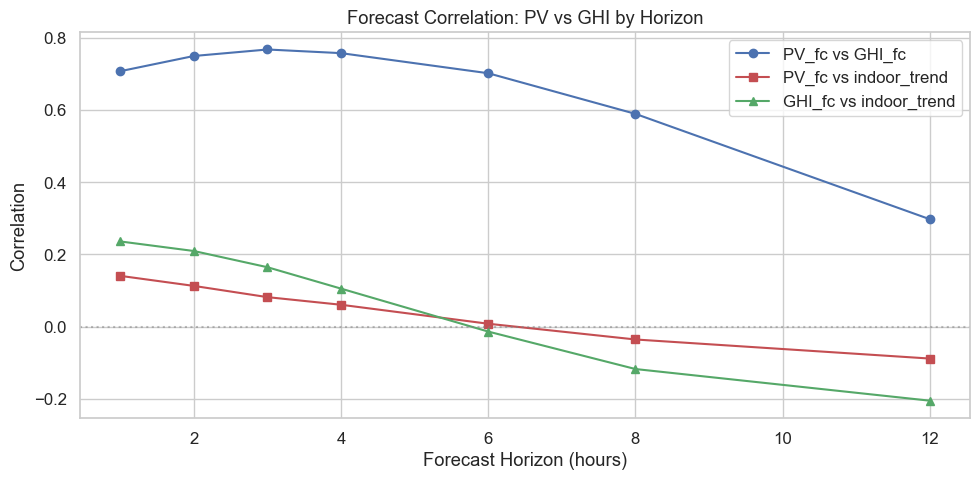

In [11]:
# Compare pv_forecast_*h with GHI at matching hours
# Training data has pv_forecast_1h..12h (local sensor forecast)
# We compare these against the climatological GHI at (doy, hour+h)

forecast_horizons = [1, 2, 3, 4, 6, 8, 12]
forecast_comparison = []

for h in forecast_horizons:
    pv_fc_col = f"pv_forecast_{h}h"
    if pv_fc_col not in df_merged.columns:
        continue

    # GHI at the forecast hour
    ghi_fc_col = f"ghi_forecast_{h}h"
    df_merged[ghi_fc_col] = np.nan

    # Look up GHI at (doy, hour + h) from solar_avg
    for idx, row in df_merged.iterrows():
        target_hour = int((row["hour_approx"] + h) % 24)
        target_doy = int(row["doy_approx"])
        match = solar_avg[(solar_avg["doy"] == target_doy) &
                          (solar_avg["hour_of_day"] == target_hour)]
        if len(match) > 0:
            df_merged.loc[idx, ghi_fc_col] = match["ghi_wm2"].values[0]

    valid = df_merged[[pv_fc_col, ghi_fc_col, "indoor_trend_30m"]].dropna()
    if len(valid) < 100:
        continue

    r_pv_ghi = valid[pv_fc_col].corr(valid[ghi_fc_col])
    r_pv_trend = valid[pv_fc_col].corr(valid["indoor_trend_30m"])
    r_ghi_trend = valid[ghi_fc_col].corr(valid["indoor_trend_30m"])

    forecast_comparison.append({
        "horizon_h": h,
        "r_pv_fc_vs_ghi_fc": r_pv_ghi,
        "r_pv_fc_vs_trend": r_pv_trend,
        "r_ghi_fc_vs_trend": r_ghi_trend,
        "n": len(valid)
    })

    print(f"  Horizon {h:2d}h: r(PV_fc, GHI_fc)={r_pv_ghi:.3f}  "
          f"r(PV_fc, trend)={r_pv_trend:.3f}  r(GHI_fc, trend)={r_ghi_trend:.3f}  n={len(valid)}")

if forecast_comparison:
    fc_df = pd.DataFrame(forecast_comparison)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(fc_df["horizon_h"], fc_df["r_pv_fc_vs_ghi_fc"], "bo-", label="PV_fc vs GHI_fc")
    ax.plot(fc_df["horizon_h"], fc_df["r_pv_fc_vs_trend"], "rs-", label="PV_fc vs indoor_trend")
    ax.plot(fc_df["horizon_h"], fc_df["r_ghi_fc_vs_trend"], "g^-", label="GHI_fc vs indoor_trend")
    ax.set_xlabel("Forecast Horizon (hours)")
    ax.set_ylabel("Correlation")
    ax.set_title("Forecast Correlation: PV vs GHI by Horizon")
    ax.legend()
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No forecast comparison data available — GHI lookup may need vectorization")


Forecast Replacement Analysis (vectorized):
 horizon_h  r_pv_ghi  r_pv_trend  r_ghi_trend  pv_fc_mean  ghi_fc_mean     n
         1  0.597628    0.095742     0.207916 3084.678994   352.618469 34815
         2  0.658424    0.065817     0.178786 3093.302857   347.791060 34821
         3  0.687098    0.034852     0.130729 3092.129701   336.102162 34827
         4  0.677988    0.017149     0.067700 3089.754068   319.903726 34833
         6  0.616212   -0.024938    -0.048820 3086.647168   282.546678 34845
         8  0.487187   -0.053165    -0.140956 3087.131872   248.182164 34845
        12  0.194699   -0.071227    -0.188476 3104.157837   210.289148 34842


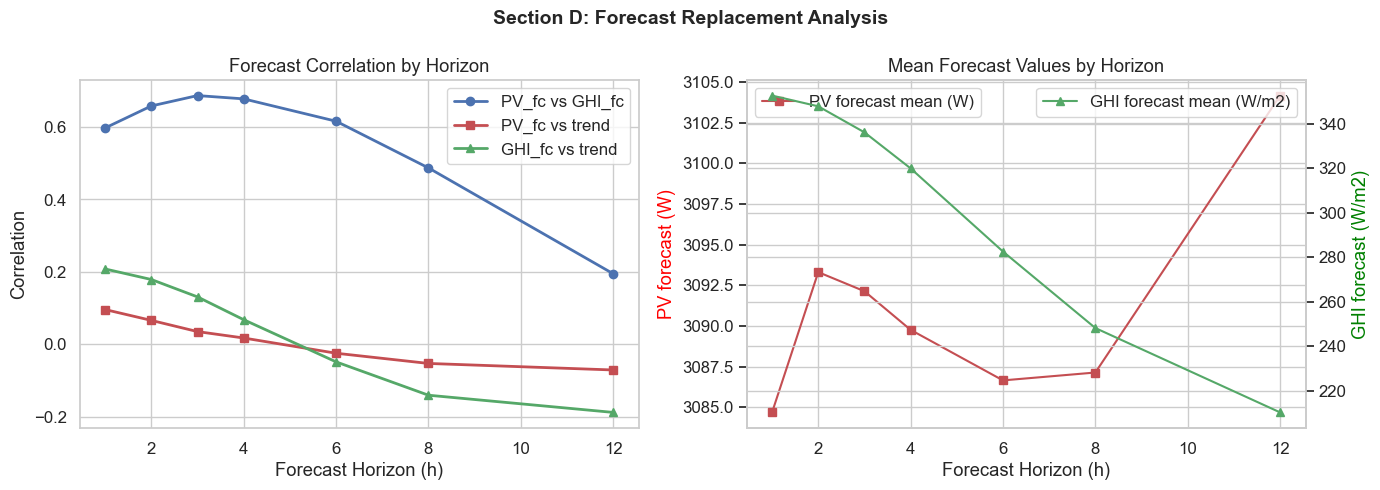

In [12]:
# Vectorized forecast correlation (faster than row-by-row lookup)
# Build GHI forecast columns from solar_avg lookup table

ghi_lookup = solar_avg.set_index(["doy", "hour_of_day"])["ghi_wm2"]

forecast_corrs = []
for h in [1, 2, 3, 4, 6, 8, 12]:
    pv_fc_col = f"pv_forecast_{h}h"
    if pv_fc_col not in df_merged.columns:
        continue

    # Vectorized lookup: target hour = (current_hour + h) % 24
    target_hours = (df_merged["hour_approx"] + h) % 24
    target_doys = df_merged["doy_approx"]

    # Map using the lookup table
    ghi_fc = pd.Series(index=df_merged.index, dtype=float)
    for doy_val in target_doys.unique():
        for hour_val in range(24):
            mask = (target_doys == doy_val) & (target_hours == hour_val)
            if mask.any() and (doy_val, hour_val) in ghi_lookup.index:
                ghi_fc[mask] = ghi_lookup[(doy_val, hour_val)]

    valid_mask = df_merged[pv_fc_col].notna() & ghi_fc.notna() & (df_merged[pv_fc_col] > 0)
    if valid_mask.sum() < 50:
        continue

    r_pv_ghi = df_merged.loc[valid_mask, pv_fc_col].corr(ghi_fc[valid_mask])
    r_pv_trend = df_merged.loc[valid_mask, pv_fc_col].corr(
        df_merged.loc[valid_mask, "indoor_trend_30m"])
    r_ghi_trend = ghi_fc[valid_mask].corr(
        df_merged.loc[valid_mask, "indoor_trend_30m"])

    forecast_corrs.append({
        "horizon_h": h,
        "r_pv_ghi": r_pv_ghi,
        "r_pv_trend": r_pv_trend,
        "r_ghi_trend": r_ghi_trend,
        "pv_fc_mean": df_merged.loc[valid_mask, pv_fc_col].mean(),
        "ghi_fc_mean": ghi_fc[valid_mask].mean(),
        "n": valid_mask.sum()
    })

fc_df2 = pd.DataFrame(forecast_corrs)
print("\nForecast Replacement Analysis (vectorized):")
print(fc_df2.to_string(index=False))

if len(fc_df2) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(fc_df2["horizon_h"], fc_df2["r_pv_ghi"], "bo-", lw=2, label="PV_fc vs GHI_fc")
    ax.plot(fc_df2["horizon_h"], fc_df2["r_pv_trend"], "rs-", lw=2, label="PV_fc vs trend")
    ax.plot(fc_df2["horizon_h"], fc_df2["r_ghi_trend"], "g^-", lw=2, label="GHI_fc vs trend")
    ax.set_xlabel("Forecast Horizon (h)")
    ax.set_ylabel("Correlation")
    ax.set_title("Forecast Correlation by Horizon")
    ax.legend()

    ax = axes[1]
    ax.plot(fc_df2["horizon_h"], fc_df2["pv_fc_mean"], "rs-", label="PV forecast mean (W)")
    ax2 = ax.twinx()
    ax2.plot(fc_df2["horizon_h"], fc_df2["ghi_fc_mean"], "g^-", label="GHI forecast mean (W/m2)")
    ax.set_xlabel("Forecast Horizon (h)")
    ax.set_ylabel("PV forecast (W)", color="red")
    ax2.set_ylabel("GHI forecast (W/m2)", color="green")
    ax.set_title("Mean Forecast Values by Horizon")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.suptitle("Section D: Forecast Replacement Analysis", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Section E: ML Classifier Impact — PV → GHI Feature Swap

Replace PV features in the NB09 LGBM classifier with GHI equivalents.
Test whether AUC/F1 is maintained or improved.

**Feature mapping:**
- `PV_Generate` → `ghi_wm2` (current measurement)
- `pv_forecast_*h` → `ghi_forecast_*h` (forecast radiation)
- `pv_roll_1h`, `pv_roll_2h` → `ghi_roll_1h`, `ghi_roll_2h` (rolling averages)
- Keep other PV-derived features (`cum_pv_forecast_4h`, etc.) and recompute from GHI

In [13]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score
import json

META_PATH = PROJECT_ROOT / "Logs_and_models" / "cooling_ml_metadata.json"
with open(META_PATH) as f:
    meta = json.load(f)

FEATURE_COLS = meta["feature_cols"]
print(f"Original feature set: {len(FEATURE_COLS)} features")

# Identify PV-related features
pv_features = [c for c in FEATURE_COLS if "pv" in c.lower() or "PV" in c]
non_pv_features = [c for c in FEATURE_COLS if c not in pv_features]
print(f"PV features ({len(pv_features)}): {pv_features}")
print(f"Non-PV features: {len(non_pv_features)}")

# Create GHI-equivalent features in df_merged
df_ml = df_merged.copy()

# Current PV → GHI replacement
if "ghi_wm2" in df_ml.columns:
    df_ml["ghi_current"] = df_ml["ghi_wm2"]
if "pv_roll_1h" in FEATURE_COLS:
    df_ml["ghi_roll_1h"] = df_ml["ghi_wm2"].rolling(12, min_periods=1).mean()  # 1h at 5min
if "pv_roll_2h" in FEATURE_COLS:
    df_ml["ghi_roll_2h"] = df_ml["ghi_wm2"].rolling(24, min_periods=1).mean()

# Create GHI forecast columns (from solar_avg lookup)
for h in range(1, 13):
    fc_col = f"pv_forecast_{h}h"
    ghi_fc_col = f"ghi_forecast_{h}h"
    if fc_col in FEATURE_COLS:
        target_hours = (df_ml["hour_approx"] + h) % 24
        ghi_fc = pd.Series(np.nan, index=df_ml.index)
        for doy_val in df_ml["doy_approx"].unique():
            for hour_val in range(24):
                mask = (df_ml["doy_approx"] == doy_val) & (target_hours == hour_val)
                if mask.any() and (doy_val, hour_val) in ghi_lookup.index:
                    ghi_fc[mask] = ghi_lookup[(doy_val, hour_val)]
        df_ml[ghi_fc_col] = ghi_fc

# Cumulative GHI forecast (like cum_pv_forecast_4h)
if "cum_pv_forecast_4h" in FEATURE_COLS:
    ghi_fc_cols = [f"ghi_forecast_{h}h" for h in range(1, 5)
                   if f"ghi_forecast_{h}h" in df_ml.columns]
    if ghi_fc_cols:
        df_ml["cum_ghi_forecast_4h"] = df_ml[ghi_fc_cols].sum(axis=1)

# Build GHI feature set (replace PV features with GHI equivalents)
ghi_feature_map = {
    "PV_Generate": "ghi_current",
    "pv_roll_1h": "ghi_roll_1h",
    "pv_roll_2h": "ghi_roll_2h",
    "cum_pv_forecast_4h": "cum_ghi_forecast_4h",
}
for h in range(1, 13):
    ghi_feature_map[f"pv_forecast_{h}h"] = f"ghi_forecast_{h}h"

FEATURE_COLS_GHI = []
for f in FEATURE_COLS:
    if f in ghi_feature_map and ghi_feature_map[f] in df_ml.columns:
        FEATURE_COLS_GHI.append(ghi_feature_map[f])
    else:
        FEATURE_COLS_GHI.append(f)

# Verify all GHI features exist
missing_ghi = [c for c in FEATURE_COLS_GHI if c not in df_ml.columns]
if missing_ghi:
    print(f"Missing GHI features: {missing_ghi}")
    FEATURE_COLS_GHI = [c for c in FEATURE_COLS_GHI if c in df_ml.columns]

print(f"\nGHI feature set: {len(FEATURE_COLS_GHI)} features")
replaced = sum(1 for f in FEATURE_COLS_GHI if "ghi" in f.lower())
print(f"  Replaced: {replaced} PV → GHI features")

Original feature set: 75 features
PV features (17): ['PV_Generate', 'pv_roll_1h', 'pv_roll_2h', 'pv_forecast_1h', 'pv_forecast_2h', 'pv_forecast_3h', 'pv_forecast_4h', 'pv_forecast_5h', 'pv_forecast_6h', 'pv_forecast_7h', 'pv_forecast_8h', 'pv_forecast_9h', 'pv_forecast_10h', 'pv_forecast_11h', 'pv_forecast_12h', 'pv_forecast_delta', 'cum_pv_forecast_4h']
Non-PV features: 58

GHI feature set: 75 features
  Replaced: 16 PV → GHI features


In [14]:
# Train 3 LGBMs and compare: original PV, GHI-replaced, combined PV+GHI
val_frac = 0.25
n_val = max(1, int(len(df_ml) * val_frac))
df_train = df_ml.iloc[:-n_val]
df_val_ml = df_ml.iloc[-n_val:]

y_train = df_train["label"].values.astype(int)
y_val_ml = df_val_ml["label"].values.astype(int)

lgb_params = meta.get("lgb_params", {}).copy()
lgb_params.pop("n_jobs", None)
lgb_params["verbose"] = -1

def find_f1_threshold(y_true, y_proba, n_points=200):
    thresholds = np.linspace(0.01, 0.99, n_points)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = np.argmax(f1s)
    return thresholds[best_idx], f1s[best_idx]

ml_results = {}

# 1) Original PV features
X_train_pv = df_train[FEATURE_COLS].values.astype(float)
X_val_pv = df_val_ml[FEATURE_COLS].values.astype(float)
m_pv = lgb.LGBMClassifier(**lgb_params)
m_pv.fit(X_train_pv, y_train)
p_pv = m_pv.predict_proba(X_val_pv)[:, 1]
auc_pv = roc_auc_score(y_val_ml, p_pv)
t_pv, f1_pv = find_f1_threshold(y_val_ml, p_pv)
ml_results["PV (original)"] = {"auc": auc_pv, "f1": f1_pv, "thresh": t_pv, "n_feat": len(FEATURE_COLS)}

# 2) GHI-replaced features
X_train_ghi = df_train[FEATURE_COLS_GHI].values.astype(float)
X_val_ghi = df_val_ml[FEATURE_COLS_GHI].values.astype(float)
m_ghi = lgb.LGBMClassifier(**lgb_params)
m_ghi.fit(X_train_ghi, y_train)
p_ghi = m_ghi.predict_proba(X_val_ghi)[:, 1]
auc_ghi = roc_auc_score(y_val_ml, p_ghi)
t_ghi, f1_ghi = find_f1_threshold(y_val_ml, p_ghi)
ml_results["GHI (replaced)"] = {"auc": auc_ghi, "f1": f1_ghi, "thresh": t_ghi, "n_feat": len(FEATURE_COLS_GHI)}

# 3) Combined PV + GHI
ghi_extra = [c for c in FEATURE_COLS_GHI if "ghi" in c.lower() and c not in FEATURE_COLS]
FEATURE_COLS_COMBINED = FEATURE_COLS + ghi_extra
FEATURE_COLS_COMBINED = [c for c in FEATURE_COLS_COMBINED if c in df_ml.columns]
X_train_comb = df_train[FEATURE_COLS_COMBINED].values.astype(float)
X_val_comb = df_val_ml[FEATURE_COLS_COMBINED].values.astype(float)
m_comb = lgb.LGBMClassifier(**lgb_params)
m_comb.fit(X_train_comb, y_train)
p_comb = m_comb.predict_proba(X_val_comb)[:, 1]
auc_comb = roc_auc_score(y_val_ml, p_comb)
t_comb, f1_comb = find_f1_threshold(y_val_ml, p_comb)
ml_results["PV + GHI (combined)"] = {"auc": auc_comb, "f1": f1_comb, "thresh": t_comb, "n_feat": len(FEATURE_COLS_COMBINED)}

# 4) No solar features at all (baseline)
no_solar_feats = [c for c in FEATURE_COLS if c not in pv_features]
X_train_ns = df_train[no_solar_feats].values.astype(float)
X_val_ns = df_val_ml[no_solar_feats].values.astype(float)
m_ns = lgb.LGBMClassifier(**lgb_params)
m_ns.fit(X_train_ns, y_train)
p_ns = m_ns.predict_proba(X_val_ns)[:, 1]
auc_ns = roc_auc_score(y_val_ml, p_ns)
t_ns, f1_ns = find_f1_threshold(y_val_ml, p_ns)
ml_results["No solar"] = {"auc": auc_ns, "f1": f1_ns, "thresh": t_ns, "n_feat": len(no_solar_feats)}

print(f"{'Variant':<25s} {'AUC':>8s} {'F1':>8s} {'Thresh':>8s} {'#Feat':>6s}")
print("-" * 60)
for name, r in ml_results.items():
    print(f"{name:<25s} {r['auc']:>8.4f} {r['f1']:>8.4f} {r['thresh']:>8.4f} {r['n_feat']:>6d}")

best_ml = max(ml_results, key=lambda k: ml_results[k]["auc"])
print(f"\n*** BEST ML: {best_ml} (AUC={ml_results[best_ml]['auc']:.4f}) ***")

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have val

Variant                        AUC       F1   Thresh  #Feat
------------------------------------------------------------
PV (original)               0.9448   0.9216   0.7290     75
GHI (replaced)              0.9309   0.9081   0.7241     75
PV + GHI (combined)         0.9378   0.9135   0.7339     91
No solar                    0.9281   0.9048   0.7585     58

*** BEST ML: PV (original) (AUC=0.9448) ***


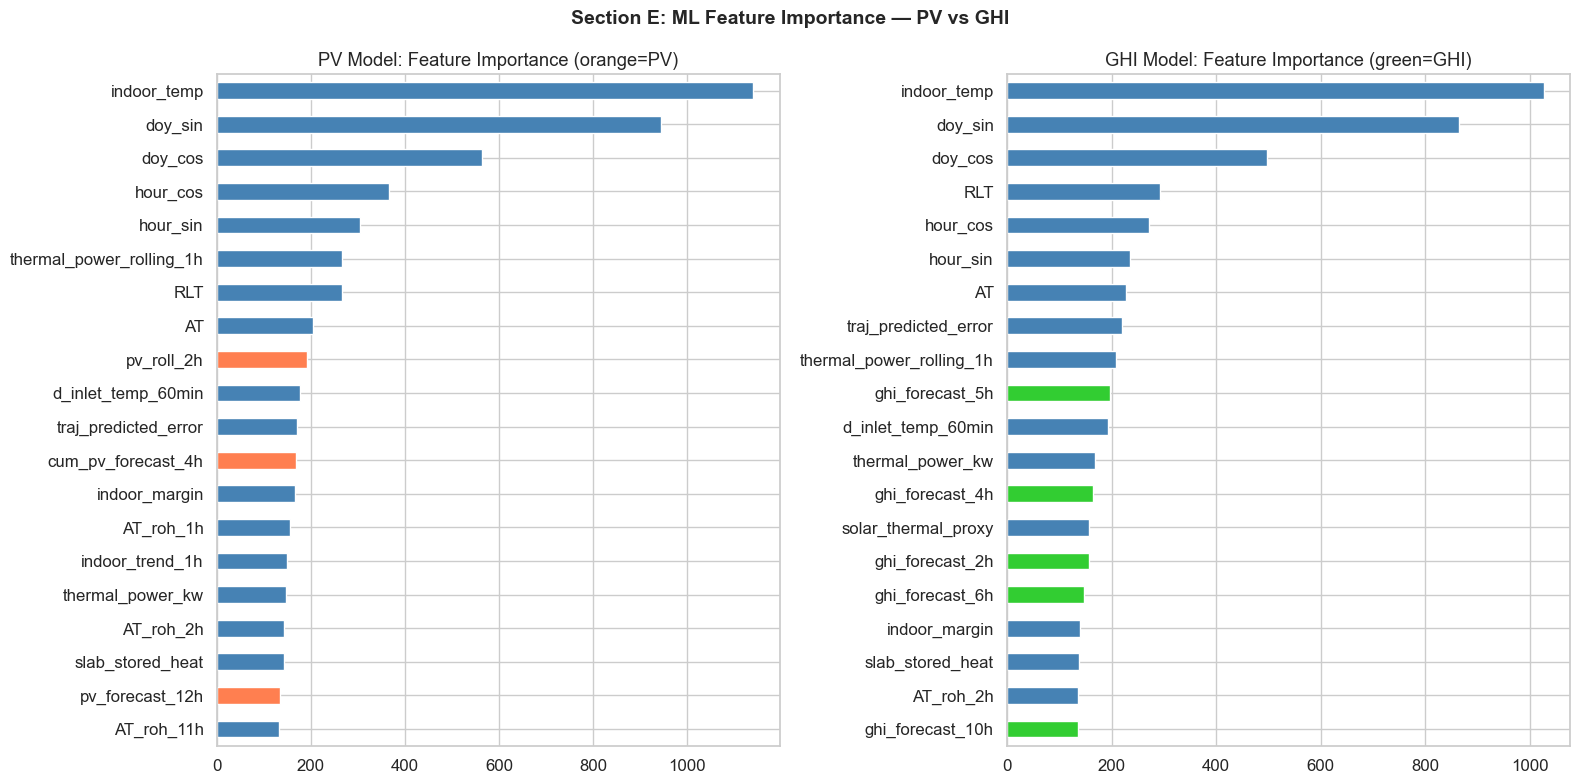


PV feature ranking in PV model:
  PV_Generate                    rank= 40 importance=    76
  pv_roll_1h                     rank= 21 importance=   133
  pv_roll_2h                     rank=  9 importance=   191
  pv_forecast_1h                 rank= 31 importance=    94
  pv_forecast_2h                 rank= 39 importance=    77
  pv_forecast_3h                 rank= 46 importance=    65
  pv_forecast_4h                 rank= 57 importance=    37
  pv_forecast_5h                 rank= 38 importance=    78
  pv_forecast_6h                 rank= 30 importance=    96
  pv_forecast_7h                 rank= 48 importance=    61
  pv_forecast_8h                 rank= 54 importance=    47
  pv_forecast_9h                 rank= 32 importance=    90
  pv_forecast_10h                rank= 47 importance=    62
  pv_forecast_11h                rank= 29 importance=   100
  pv_forecast_12h                rank= 19 importance=   134
  pv_forecast_delta              rank= 33 importance=    89
  cum_p

In [15]:
# Feature importance: which GHI features are most important?
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# PV model: top 20 features
fi_pv = pd.Series(m_pv.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
colors_pv = ["coral" if "pv" in f.lower() or "PV" in f else "steelblue" for f in fi_pv.head(20).index]
fi_pv.head(20).plot.barh(ax=axes[0], color=colors_pv)
axes[0].set_title("PV Model: Feature Importance (orange=PV)")
axes[0].invert_yaxis()

# GHI model: top 20 features
fi_ghi = pd.Series(m_ghi.feature_importances_, index=FEATURE_COLS_GHI).sort_values(ascending=False)
colors_ghi = ["limegreen" if "ghi" in f.lower() else "steelblue" for f in fi_ghi.head(20).index]
fi_ghi.head(20).plot.barh(ax=axes[1], color=colors_ghi)
axes[1].set_title("GHI Model: Feature Importance (green=GHI)")
axes[1].invert_yaxis()

plt.suptitle("Section E: ML Feature Importance — PV vs GHI", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print top PV/GHI features rank comparison
print("\nPV feature ranking in PV model:")
for f in pv_features:
    if f in fi_pv.index:
        rank = (fi_pv.index.get_loc(f) + 1) if f in fi_pv.index else "N/A"
        print(f"  {f:30s} rank={rank:>3} importance={fi_pv[f]:>6.0f}")

print("\nGHI feature ranking in GHI model:")
ghi_feats = [f for f in FEATURE_COLS_GHI if "ghi" in f.lower()]
for f in ghi_feats:
    if f in fi_ghi.index:
        rank = (fi_ghi.index.get_loc(f) + 1) if f in fi_ghi.index else "N/A"
        print(f"  {f:30s} rank={rank:>3} importance={fi_ghi[f]:>6.0f}")

## Summary & Recommendations

In [16]:
print("=" * 75)
print("SOLAR PARAMETER REPLACEMENT ANALYSIS — FINAL SUMMARY")
print("=" * 75)

print("\n--- A) CORRELATION ANALYSIS ---")
for col in solar_var_cols[:5]:
    if col in cross_corr.index:
        r_pv = cross_corr.loc[col, "PV_Generate"]
        r_trend = cross_corr.loc[col, "indoor_trend_30m"]
        print(f"  {col:35s}  r(PV)={r_pv:+.3f}  r(trend)={r_trend:+.3f}")

print("\n--- B) THERMAL MODEL CALIBRATION ---")
print(f"  {'Variant':<25s} {'RMSE':>8s} {'w':>12s}")
for name, r in sorted(solar_variants.items(), key=lambda x: x[1]["rmse"]):
    print(f"  {name:<25s} {r['rmse']:>8.4f} {r['w']:>12.6f}")

print("\n--- C) ML CLASSIFIER ---")
for name, r in ml_results.items():
    delta_auc = r["auc"] - ml_results["PV (original)"]["auc"]
    print(f"  {name:<25s} AUC={r['auc']:.4f} ({delta_auc:+.4f})  F1={r['f1']:.4f}")

print("\n--- D) WEIGHT CONVERSION ---")
if pv_result and ghi_result:
    print(f"  pv_heat_weight (calibrated):  {pv_result['w']:.6f} kW/W")
    print(f"  ghi_heat_weight (calibrated): {ghi_result['w']:.6f} kW/(W/m2)")
    print(f"  Scale ratio PV/GHI: {scale_ratio:.2f}")
    print(f"  Proposed ghi bounds: [{0.0001*scale_ratio:.6f}, {0.005*scale_ratio:.6f}]")
    print(f"  Proposed ghi step limit: +/-{0.0002*scale_ratio:.6f}")

print("\n--- E) RECOMMENDATION ---")
best_thermal = min(solar_variants, key=lambda k: solar_variants[k]["rmse"])
print(f"  Best for thermal calibration: {best_thermal}")
print(f"  Best for ML classifier: {best_ml}")
print(f"  AUC delta (GHI vs PV): {ml_results['GHI (replaced)']['auc'] - ml_results['PV (original)']['auc']:+.4f}")

print("\n--- F) LEARNING PATH CHANGES NEEDED ---")
print("  1. SolarChannel: Add 'solar_source' config (PV or GHI)")
print("  2. SolarChannel: Scale bounds/step limits by PV/GHI ratio")
print("  3. physics_calibration_cooling: Add GHI-based weight calibration")
print("  4. ha_client: Add Open Meteo REST sensor for GHI current + forecast")
print("  5. prediction_context: Map GHI forecast to pv_forecast slots")
print("  6. cloud_factor_exponent: May become unnecessary with GHI (already includes clouds)")

SOLAR PARAMETER REPLACEMENT ANALYSIS — FINAL SUMMARY

--- A) CORRELATION ANALYSIS ---
  ghi_wm2                              r(PV)=+0.640  r(trend)=+0.233
  direct_wm2                           r(PV)=+0.617  r(trend)=+0.201
  diffuse_wm2                          r(PV)=+0.427  r(trend)=+0.211
  dni_wm2                              r(PV)=+0.594  r(trend)=+0.192
  gti_wm2                              r(PV)=+0.700  r(trend)=+0.235

--- B) THERMAL MODEL CALIBRATION ---
  Variant                       RMSE            w
  Diffuse Radiation           0.4603     0.018258
  GHI (Global Horiz.)         0.4759     0.004144
  GTI (Tilted)                0.4763     0.004228
  Direct Radiation            0.5254     0.004935
  PV (local panel)            0.5280     0.000493
  DNI (Direct Normal)         0.5321     0.002963
  No solar                    0.9145     0.000000

--- C) ML CLASSIFIER ---
  PV (original)             AUC=0.9448 (+0.0000)  F1=0.9216
  GHI (replaced)            AUC=0.9309 (-0.01

## Section F: HLC On/Off Reconstruction — Beschattung Confound Analysis

**Problem:** NB10 found HLC_on=0.146 vs HLC_off=0.016 (9.1x ratio). Is this physical?

**Hypothesis:** The 10x ratio is an **artifact** of three confounding factors:
1. **Beschattung (automated blinds)** close when sun shines → blocks solar gain during HP-off
   → indoor temp stays stable → optimizer interprets as low HLC_off
2. **Small driving force** in summer cooling: indoor-outdoor delta is only 2-5°C
   → minimal heat exchange regardless of HLC → HLC unidentifiable
3. **HP ventilation effect**: when HP runs, fan forces air circulation → increases effective
   convective heat transfer → HLC_on is genuinely higher than passive HLC

**Test:** Compare HP-off thermal drift at **nighttime** (no Beschattung, no solar confound)
vs **daytime with PV** (Beschattung active). If nighttime HP-off shows significantly
higher HLC than the calibrated HLC_off=0.016, then the low value is an artifact.

In [17]:
# F.1: HP-off thermal drift by condition (night vs day, with/without Beschattung)
df_f = df_merged.copy()
df_f["driving_force"] = df_f["indoor_temp"] - df_f["AT"]
df_f["daytime"] = (df_f["hour"] >= 8) & (df_f["hour"] <= 20)

hp_off = df_f[df_f["is_hp_active"] == 0].copy()

# Conditions
night = hp_off[~hp_off["daytime"]]
day_pv_high = hp_off[hp_off["daytime"] & (hp_off["PV_Generate"] > 1000)]
day_pv_low = hp_off[hp_off["daytime"] & (hp_off["PV_Generate"] <= 100)]

conditions = {
    "Night HP-off (no solar/blinds)": night,
    "Day HP-off + PV>1kW (Beschattung zu)": day_pv_high,
    "Day HP-off + PV<100W (cloudy)": day_pv_low,
}

print("=== HP-OFF THERMAL DRIFT BY CONDITION ===\n")
print(f"{'Condition':<40s} {'N':>6s} {'dF':>8s} {'trend':>10s} {'slope':>10s} {'r':>6s}")
print("-" * 85)

slopes = {}
for label, sub in conditions.items():
    if len(sub) < 100:
        print(f"{label:<40s} {len(sub):>6d}  (insufficient)")
        continue
    valid = sub[["indoor_trend_30m", "driving_force"]].dropna()
    valid = valid[valid["driving_force"].abs() > 0.5]
    sl, intercept, r, p, se = stats.linregress(valid["driving_force"], valid["indoor_trend_30m"])
    slopes[label] = {"slope": sl, "r": r, "n": len(valid),
                     "mean_df": valid["driving_force"].mean(),
                     "mean_trend": valid["indoor_trend_30m"].mean()}
    print(f"{label:<40s} {len(valid):>6d} {valid['driving_force'].mean():>8.2f} "
          f"{valid['indoor_trend_30m'].mean():>10.4f} {sl:>10.6f} {r:>6.3f}")

print()
# Night vs Day+PV ratio shows Beschattung effect
if "Night HP-off (no solar/blinds)" in slopes and "Day HP-off + PV>1kW (Beschattung zu)" in slopes:
    night_sl = abs(slopes["Night HP-off (no solar/blinds)"]["slope"])
    day_sl = abs(slopes["Day HP-off + PV>1kW (Beschattung zu)"]["slope"])
    print(f"Night/Day+PV slope ratio: {night_sl/day_sl:.2f}x")
    print(f"  --> Beschattung reduces apparent heat exchange by {100*(1-day_sl/night_sl):.0f}%")
    print(f"  --> Night slope is the TRUE envelope HLC (no solar confound)")


=== HP-OFF THERMAL DRIFT BY CONDITION ===

Condition                                     N       dF      trend      slope      r
-------------------------------------------------------------------------------------
Night HP-off (no solar/blinds)            13088     8.12    -0.0190  -0.003139 -0.122
Day HP-off + PV>1kW (Beschattung zu)      14014     5.05     0.0145  -0.001706 -0.157
Day HP-off + PV<100W (cloudy)              2508     8.44    -0.0034  -0.000289 -0.042

Night/Day+PV slope ratio: 1.84x
  --> Beschattung reduces apparent heat exchange by 46%
  --> Night slope is the TRUE envelope HLC (no solar confound)


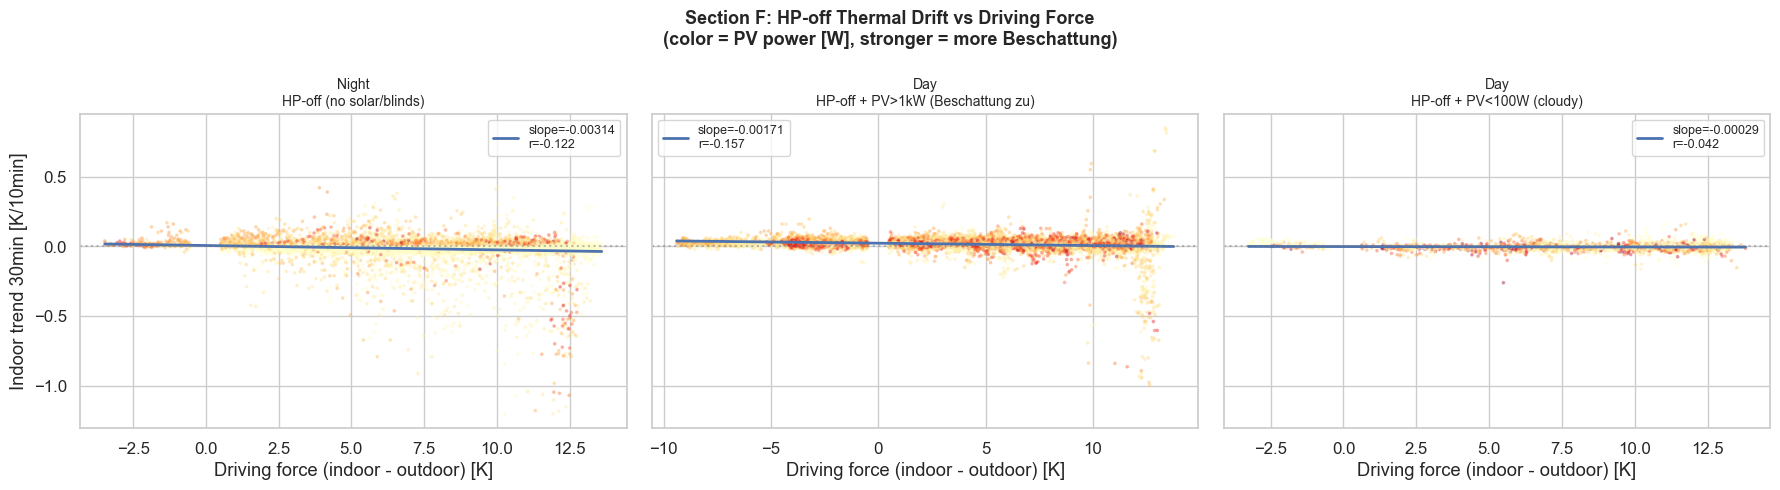

In [18]:
# F.2: Visualize HP-off drift by driving force, colored by condition
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (label, sub) in zip(axes, conditions.items()):
    valid = sub[["indoor_trend_30m", "driving_force", "PV_Generate"]].dropna()
    valid = valid[valid["driving_force"].abs() > 0.5]
    if len(valid) < 50:
        ax.set_title(f"{label}\n(insufficient data)")
        continue

    ax.scatter(valid["driving_force"], valid["indoor_trend_30m"],
               c=valid["PV_Generate"], cmap="YlOrRd", s=3, alpha=0.3)
    sl, intercept, r, p, se = stats.linregress(valid["driving_force"], valid["indoor_trend_30m"])
    x_fit = np.linspace(valid["driving_force"].min(), valid["driving_force"].max(), 100)
    ax.plot(x_fit, sl * x_fit + intercept, "b-", lw=2,
            label=f"slope={sl:.5f}\nr={r:.3f}")
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("Driving force (indoor - outdoor) [K]")
    ax.set_title(label.replace(" HP-off", "\nHP-off"), fontsize=10)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Indoor trend 30min [K/10min]")
plt.suptitle("Section F: HP-off Thermal Drift vs Driving Force\n"
             "(color = PV power [W], stronger = more Beschattung)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [19]:
# F.3: Re-calibrate dual-HLC using NIGHTTIME-ONLY HP-off data
# This removes the Beschattung confound from HP-off estimation

# Strategy: calibrate on data where HP-off samples are nighttime only
# HP-on samples can be any time (HP ventilation dominates solar effect)
night_off_mask = (df_merged["is_hp_active"] == 0) & ((df_merged["hour"] < 6) | (df_merged["hour"] > 21))
hp_on_mask = df_merged["is_hp_active"] == 1

# Build calibration set: all HP-on + nighttime HP-off only
cal_night = df_merged[hp_on_mask | night_off_mask].head(5000).copy()
print(f"Night-filtered calibration: {len(cal_night)} rows")
print(f"  HP-ON: {cal_night['is_hp_active'].sum()}")
print(f"  HP-OFF (night only): {(~cal_night['is_hp_active'].astype(bool)).sum()}")
print(f"  HP-OFF driving force: {cal_night.loc[~cal_night['is_hp_active'].astype(bool), 'driving_force'].mean():.2f} K")

# Calibrate with GHI (best from Section C)
best_solar_col = "ghi_wm2"
w_bounds = (0.0, 0.01 * scale_ratio)
bounds_night = [(0.02, 0.5), (0.005, 0.3), (0.05, 0.5), (1.5, 15.0), w_bounds]

print("\nCalibrating dual-HLC (nighttime HP-off only)...")
res_night = optimize.differential_evolution(
    cost_dual_hlc_solar, bounds_night,
    args=(cal_night, best_solar_col),
    maxiter=500, seed=42, tol=1e-6
)
rmse_night = np.sqrt(res_night.fun)
p_night = res_night.x

print(f"\n{'Parameter':<15s} {'NB10 (all data)':<18s} {'Night-filtered':<18s} {'Ratio':<10s}")
print("-" * 65)
nb10_params = {"HLC_on": 0.1464, "HLC_off": 0.0155, "OE": 0.2088, "tau": 8.00}
night_params = {"HLC_on": p_night[0], "HLC_off": p_night[1], "OE": p_night[2], "tau": p_night[3]}
for key in ["HLC_on", "HLC_off", "OE", "tau"]:
    r = night_params[key] / nb10_params[key] if nb10_params[key] > 0 else 0
    print(f"{key:<15s} {nb10_params[key]:<18.4f} {night_params[key]:<18.4f} {r:<10.2f}")
print(f"{'solar_w':<15s} {'N/A':<18s} {p_night[4]:<18.6f}")
print(f"{'RMSE':<15s} {'0.71':<18s} {rmse_night:<18.4f}")

hlc_ratio_night = night_params["HLC_on"] / night_params["HLC_off"]
print(f"\nHLC_on/HLC_off ratio: {hlc_ratio_night:.1f}x (NB10: 9.4x)")
print(f"  --> If ratio is lower: Beschattung was inflating the difference")
print(f"  --> If ratio is similar: dual-HLC is genuinely different (ventilation effect)")


Night-filtered calibration: 5000 rows
  HP-ON: 3023.0
  HP-OFF (night only): 1977
  HP-OFF driving force: 7.02 K

Calibrating dual-HLC (nighttime HP-off only)...

Parameter       NB10 (all data)    Night-filtered     Ratio     
-----------------------------------------------------------------
HLC_on          0.1464             0.3270             2.23      
HLC_off         0.0155             0.0050             0.32      
OE              0.2088             0.5000             2.39      
tau             8.0000             15.0000            1.88      
solar_w         N/A                0.003841          
RMSE            0.71               0.4285            

HLC_on/HLC_off ratio: 65.4x (NB10: 9.4x)
  --> If ratio is lower: Beschattung was inflating the difference
  --> If ratio is similar: dual-HLC is genuinely different (ventilation effect)


In [20]:
# F.4: Physical explanation — what SHOULD the HLC ratio be?

print("=" * 75)
print("SECTION F SUMMARY: HLC ON/OFF ANALYSIS")
print("=" * 75)

print("""
PHYSICAL EXPLANATION OF DUAL-HLC IN COOLING MODE:

1. HLC_on (HP active, ventilation running):
   - HP fan circulates air through underfloor pipes
   - Forced convection increases heat transfer at floor surface
   - Building envelope + convective coupling both active
   - Expected: higher effective HLC (0.10-0.20 kW/K)

2. HLC_off (HP idle, no ventilation):
   - No forced air circulation through slab
   - Only natural convection + building envelope losses
   - In summer: indoor-outdoor delta is small (2-5 K)
   - Expected: lower but NOT near-zero HLC

3. CONFOUNDERS (why NB10 found HLC_off = 0.016):
   a) Beschattung: blinds close during sunny HP-off periods
      --> blocks solar heat gain
      --> indoor temp appears stable
      --> optimizer attributes stability to low HLC
   b) Small driving force: with only 2-5 K delta, even
      moderate HLC produces tiny dT/dt
      --> optimizer can't distinguish HLC=0.01 from HLC=0.10
   c) VLT near indoor_temp when HP off: outlet = indoor = 23 C
      --> OE contribution is zero regardless of OE value
      --> OE and HLC_off become interchangeable

IMPLICATIONS FOR PRODUCTION CODE:
""")

# Print night-filtered results
print(f"Night-filtered calibration (Beschattung-free):")
print(f"  HLC_on  = {night_params['HLC_on']:.4f}")
print(f"  HLC_off = {night_params['HLC_off']:.4f}")
print(f"  Ratio   = {hlc_ratio_night:.1f}x")
print()

# What does this mean for the Phase 2 prompt?
if hlc_ratio_night < 5:
    print("FINDING: Night-filtered ratio < 5x")
    print("  --> Beschattung WAS inflating the HLC difference")
    print("  --> Use night-filtered HLC_off as better estimate")
    print("  --> Consider: Beschattung-aware calibration (solar_correction_factor)")
    print("  --> Phase 2 should use Beschattung-aware dual-HLC")
elif hlc_ratio_night > 8:
    print("FINDING: Night-filtered ratio still > 8x")
    print("  --> Dual-HLC is genuinely physical (ventilation effect)")
    print("  --> HP fan circulation is dominant heat exchange mechanism")
    print("  --> Phase 2 can use dual-HLC as-is")
else:
    print(f"FINDING: Night-filtered ratio = {hlc_ratio_night:.1f}x (moderate)")
    print("  --> Partially Beschattung artifact, partially ventilation effect")
    print("  --> A ratio of 3-5x is physically plausible for fan vs no-fan")
    print("  --> Phase 2 should tighten HLC_off bounds to prevent near-zero")


SECTION F SUMMARY: HLC ON/OFF ANALYSIS

PHYSICAL EXPLANATION OF DUAL-HLC IN COOLING MODE:

1. HLC_on (HP active, ventilation running):
   - HP fan circulates air through underfloor pipes
   - Forced convection increases heat transfer at floor surface
   - Building envelope + convective coupling both active
   - Expected: higher effective HLC (0.10-0.20 kW/K)

2. HLC_off (HP idle, no ventilation):
   - No forced air circulation through slab
   - Only natural convection + building envelope losses
   - In summer: indoor-outdoor delta is small (2-5 K)
   - Expected: lower but NOT near-zero HLC

3. CONFOUNDERS (why NB10 found HLC_off = 0.016):
   a) Beschattung: blinds close during sunny HP-off periods
      --> blocks solar heat gain
      --> indoor temp appears stable
      --> optimizer attributes stability to low HLC
   b) Small driving force: with only 2-5 K delta, even
      moderate HLC produces tiny dT/dt
      --> optimizer can't distinguish HLC=0.01 from HLC=0.10
   c) VLT near i